# Reactor Browser With the Current `fusdb_pyomo` API

This notebook keeps the broad reactor overview, but rebuilds it with the
current reactor objects, direct variable access, and a simpler scan workflow.
        


In [ ]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

root = Path.cwd().resolve()
while root != root.parent and not (root / "src" / "fusdb").is_dir():
    root = root.parent

src_path = str(root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

warnings.filterwarnings("ignore", message="Multiple registered relations define outputs.*")

from fusdb import Reactor, Variable
from fusdb.relations.confinement.LHtransition import lh_transition_power
from fusdb.relations.geometry.plasma_geometry import (
    inverse_aspect_ratio,
    sauter_plasma_cross_sectional_length,
    sauter_plasma_surface,
)


In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

reactors = {}
for reactor_dir in sorted((root / "reactors").iterdir()):
    yaml_path = reactor_dir / "reactor.yaml"
    if not yaml_path.exists():
        continue
    reactor = Reactor.from_yaml(yaml_path)
    reactors[reactor_dir.name] = reactor
    print(f"Loaded {reactor_dir.name}: {reactor}")
        


Loaded ARC_2015: Reactor(name='ARC 2015', mode='verify', variables=33, tags=('tokamak', 'compact_tokamak', 'i_mode'))
Loaded DEMO_2022: Reactor(name='EU-DEMO 2022', mode='verify', variables=24, tags=('tokamak', 'h_mode'))
Loaded HAMMIR: Reactor(name='Hammir 2024', mode='verify', variables=3, tags=('mirror',))
Loaded INFINITY_TWO: Reactor(name='INFINITY TWO 2025', mode='verify', variables=8, tags=('stellarator',))
Loaded STELLARIS: Reactor(name='Stellaris 2025 - Point A', mode='verify', variables=16, tags=('stellarator',))
Loaded STEP_2024: Reactor(name='STEP 2024 EB-CC', mode='verify', variables=17, tags=('tokamak', 'spherical_tokamak', 'h_mode'))


In [3]:
rows = []
for reactor_id, reactor in reactors.items():
    rows.append(
        {
            "reactor": reactor_id,
            "name": reactor.name,
            "year": reactor.year,
            "organization": reactor.organization,
            "country": reactor.country,
            "tags": ", ".join(reactor.tags),
            "R": reactor.get_variable("R").value if reactor.get_variable("R") is not None else None,
            "a": reactor.get_variable("a").value if reactor.get_variable("a") is not None else None,
            "A": reactor.get_variable("A").value if reactor.get_variable("A") is not None else None,
            "B0": reactor.get_variable("B0").value if reactor.get_variable("B0") is not None else None,
            "P_fus": reactor.get_variable("P_fus").value if reactor.get_variable("P_fus") is not None else None,
            "tau_E": reactor.get_variable("tau_E").value if reactor.get_variable("tau_E") is not None else None,
        }
    )

comparison = pd.DataFrame(rows).sort_values(["year", "reactor"], na_position="last")
display(comparison)
        


,reactor,name,year,organization,country,tags,R,a,A,B0,P_fus,tau_E
0,ARC_2015,ARC 2015,2015,MIT,USA,"tokamak, compact_tokamak, i_mode",3.30,1.13,2.92,9.20,5.250000e+08,0.64
1,DEMO_2022,EU-DEMO 2022,2022,EUROFUSION,EUU,"tokamak, h_mode",9.00,2.90,3.10,5.86,2.000000e+09,NaN
2,HAMMIR,Hammir 2024,2024,Realta,None,mirror,NaN,NaN,NaN,NaN,NaN,NaN
5,STEP_2024,STEP 2024 EB-CC,2024,UKAEA,GBR,"tokamak, spherical_tokamak, h_mode",3.60,NaN,1.80,3.20,1.560000e+09,NaN
3,INFINITY_TWO,INFINITY TWO 2025,2025,TypeOne Energy,None,stellarator,12.50,1.25,NaN,NaN,8.000000e+08,1.70
4,STELLARIS,Stellaris 2025 - Point A,2025,Proxima,None,stellarator,12.74,1.30,9.80,9.00,2.700000e+09,1.46


In [4]:
reactor = Reactor.from_yaml(root / "reactors" / "DEMO_2022" / "reactor.yaml")
reactor.relation_include = ("P_sep ratio",)
reactor.mode = "verify"

if reactor.get_variable("P_sep_over_R") is not None:
    reactor.get_variable("P_sep_over_R").value = None
    reactor.get_variable("P_sep_over_R").fixed = False

result = reactor.run(solver="highs")
verify_table = pd.DataFrame(
    [
        {
            "reactor": "DEMO_2022",
            "feasible": result["feasible"],
            "P_sep": result["variables"].get("P_sep"),
            "R": result["variables"].get("R"),
            "P_sep_over_R": result["variables"].get("P_sep_over_R"),
        }
    ]
)
display(verify_table)


ERROR: evaluating object as numeric value: P_sep_over_R
        (object: <class 'pyomo.core.base.var.ScalarVar'>)
    No value for uninitialized ScalarVar object P_sep_over_R
ERROR: evaluating object as numeric value: P_sep_over_R
        (object: <class 'pyomo.core.base.var.ScalarVar'>)
    No value for uninitialized ScalarVar object P_sep_over_R
ERROR: evaluating object as numeric value: rel_0_P_sep_ratio.slack_0
        (object: <class 'pyomo.core.base.var.ScalarVar'>)
    No value for uninitialized ScalarVar object rel_0_P_sep_ratio.slack_0


,reactor,feasible,P_sep,R,P_sep_over_R
0,DEMO_2022,False,170400000.0,9.0,None


In [5]:
demo_scan = Reactor.from_yaml(root / "reactors" / "DEMO_2022" / "reactor.yaml")
scan_T = np.linspace(8.0, 18.0, 9)
scan_n = np.linspace(0.7e20, 1.3e20, 9)
scan_rows = []

for T_avg_value in scan_T:
    for n_avg_value in scan_n:
        reactor = Reactor.from_yaml(root / "reactors" / "DEMO_2022" / "reactor.yaml")
        reactor.variables["T_avg"].value = float(T_avg_value)

        n_avg_variable = reactor.get_variable("n_avg")
        if n_avg_variable is None:
            n_avg_variable = Variable(name="n_avg", value=float(n_avg_value))
            reactor.add_variable(n_avg_variable)
        else:
            n_avg_variable.value = float(n_avg_value)

        R_value = reactor.get_variable("R").value
        a_value = reactor.get_variable("a").value
        eps_value = float(inverse_aspect_ratio.func(R_value, a_value))
        kappa_95_value = reactor.get_variable("kappa_95").value
        delta_95_value = reactor.get_variable("delta_95").value
        kappa_value = 1.12 * kappa_95_value
        delta_value = 1.5 * delta_95_value
        squareness_value = reactor.get_variable("squareness").value or 0.0
        L_p_value = float(sauter_plasma_cross_sectional_length.func(a_value, kappa_value, delta_value, squareness_value))
        A_p_value = float(sauter_plasma_surface.func(R_value, delta_value, eps_value, L_p_value))
        P_LH_value = float(lh_transition_power.func(n_avg_value, reactor.get_variable("B0").value, A_p_value))

        scan_rows.append(
            {
                "T_avg": T_avg_value,
                "n_avg": n_avg_value,
                "A_p": A_p_value,
                "P_LH": P_LH_value,
            }
        )

scan_table = pd.DataFrame(scan_rows)
display(scan_table.head(12))


,T_avg,n_avg,A_p,P_LH
0,8.00,7.000000e+19,1554.405045,1.574849e+08
1,8.00,7.750000e+19,1554.405045,1.694076e+08
2,8.00,8.500000e+19,1554.405045,1.810076e+08
3,8.00,9.250000e+19,1554.405045,1.923212e+08
4,8.00,1.000000e+20,1554.405045,2.033778e+08
5,8.00,1.075000e+20,1554.405045,2.142019e+08
6,8.00,1.150000e+20,1554.405045,2.248143e+08
7,8.00,1.225000e+20,1554.405045,2.352324e+08
8,8.00,1.300000e+20,1554.405045,2.454714e+08
9,9.25,7.000000e+19,1554.405045,1.574849e+08


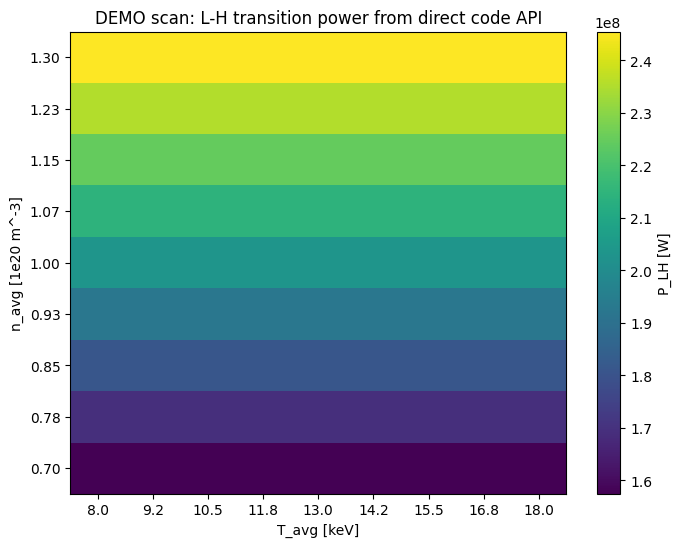

In [6]:
import matplotlib.pyplot as plt

pivot = scan_table.pivot(index="n_avg", columns="T_avg", values="P_LH")
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(pivot.values, origin="lower", aspect="auto")
ax.set_xticks(range(len(pivot.columns)), [f"{value:.1f}" for value in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [f"{value/1e20:.2f}" for value in pivot.index])
ax.set_xlabel("T_avg [keV]")
ax.set_ylabel("n_avg [1e20 m^-3]")
ax.set_title("DEMO scan: L-H transition power from direct code API")
fig.colorbar(image, ax=ax, label="P_LH [W]")
plt.show()
        
